# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Pares Tweets-Reply**

In [3]:
# baixando dataset para o collab
import gdown

file_class_caio = "1BZ1UGqv7IlaA7AGCDJG0nqOt2-ZrObAc"
file_class_victor = "16oo75d3yqJJS3rBXPIbKbFYfi7GzLQpk"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Aborto_reply_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_reply_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1BZ1UGqv7IlaA7AGCDJG0nqOt2-ZrObAc
To: /content/Aborto_reply_caio.csv
100%|██████████| 514k/514k [00:00<00:00, 93.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=16oo75d3yqJJS3rBXPIbKbFYfi7GzLQpk
To: /content/Aborto_reply_victor.csv
100%|██████████| 514k/514k [00:00<00:00, 85.2MB/s]


'Aborto_reply_victor.csv'

In [4]:
#carregando o dataset
df_caio = pd.read_csv ("Aborto_reply_caio.csv")
df_victor = pd.read_csv ("Aborto_reply_victor.csv")

In [5]:
#numero total de instancias no dataset
df_caio.shape

(2051, 4)

In [6]:
#numero total de instancias no dataset
df_victor.shape

(2051, 4)

In [7]:
df_caio.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1,0.0
6,É fácil defender o aborto sendo que você já na...,Há se as pessoas sobessem o mal que trszem par...,1,0.0
7,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Linda passagem da Bíblia. #AbortoNAO,1,0.0
8,Bolsominions estão revoltados pq STF pode perm...,É sobre as mulheres terem escolha. Se uma gest...,1,0.0
9,"O que a Bíblia fala sobre o aborto? ""Antes qu...",#AbortoNAO Minha nossa! Isso não!,1,-1.0


In [8]:
df_victor.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1,-1.0
6,É fácil defender o aborto sendo que você já na...,Há se as pessoas sobessem o mal que trszem par...,1,0.0
7,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Linda passagem da Bíblia. #AbortoNAO,1,0.0
8,Bolsominions estão revoltados pq STF pode perm...,É sobre as mulheres terem escolha. Se uma gest...,1,0.0
9,"O que a Bíblia fala sobre o aborto? ""Antes qu...",#AbortoNAO Minha nossa! Isso não!,1,-1.0


In [9]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem


In [10]:
for i in range(100):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [11]:
confusion

array([[83.,  1.,  1.],
       [ 0., 14.,  0.],
       [ 0.,  0.,  1.]])

In [12]:
idx_diff

[5, 79]

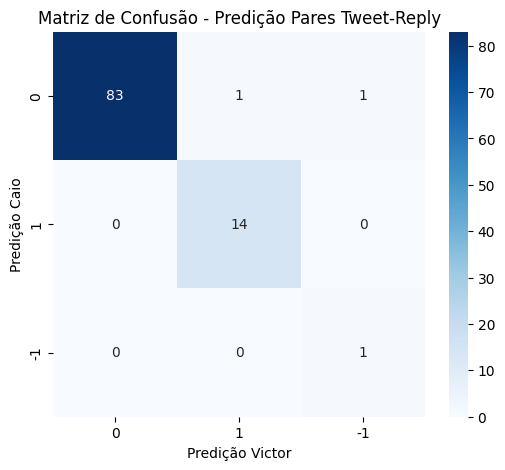

In [13]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Reply")
plt.show()

In [14]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Bora subir, robozada?   #AbortoNao
Tweet 2:  Gostaria de informar que devido a grande repercussão do vídeo de Araraquara, o jornalista foi demitido. Mas queremos mais, muito mais; queremos que o Ministério Público investigue todos os contratos feitos entre a prefeitura, as mídias, rádio e televisão de Araraquara #AbortoNAO
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Vamos subir #AbortoNao .  STF quer aprovar medida em plena pandemia.
Tweet 2:  ok mo calma aí  #AbortoSim
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito



# **Pares Tweets-Quotes**

In [15]:
file_class_caio_quotes = "1yWYkXSwkkcH0ub_zIX30ZUGkEYSnLqQi"
file_class_victor_quotes = "1gXbXkJWbnrcipbLXFXRNg5s9ySU4muQs"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_quotes}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_quotes}"

gdown.download(url_1, "Aborto_quotes_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_quotes_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1yWYkXSwkkcH0ub_zIX30ZUGkEYSnLqQi
To: /content/Aborto_quotes_caio.csv
100%|██████████| 775k/775k [00:00<00:00, 99.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gXbXkJWbnrcipbLXFXRNg5s9ySU4muQs
To: /content/Aborto_quotes_victor.csv
100%|██████████| 775k/775k [00:00<00:00, 62.3MB/s]


'Aborto_quotes_victor.csv'

In [16]:
df_caio_quotes = pd.read_csv ("Aborto_quotes_caio.csv")
df_victor_quotes = pd.read_csv ("Aborto_quotes_victor.csv")

In [17]:
confusion_quotes = np.zeros((3,3))


In [18]:
idx_diff_quotes = []

In [19]:
for i in range(100):
  caio = int(df_caio_quotes.iloc[i]["Conflict"])
  victor = int(df_victor_quotes.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_quotes[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_quotes.append(i)


In [20]:
confusion_quotes

array([[71.,  1.,  4.],
       [ 0., 21.,  3.],
       [ 0.,  0.,  0.]])

In [21]:
idx_diff_quotes

[11, 24, 33, 34, 66, 70, 82, 89]

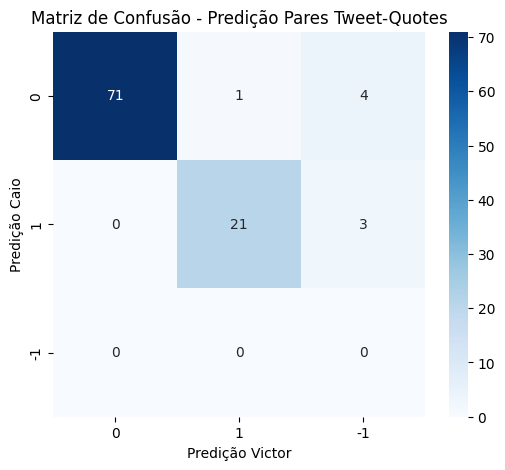

In [22]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_quotes, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Quotes")
plt.show()

In [23]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_quotes)):
  print("Tweet 1: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_1"])
  print("Tweet 2: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print()

Tweet 1:  A quem caberá decidir sobre a vida de um anjo? Não está se discutindo o direito da mulher interromper uma gravidez indesejada, pois se isso ela cometer a sua pena será “sui gêneris” . O que está se discutindo são  os lucros da clínicas de aborto que desejam faturar livremente.
Tweet 2:  A mulher tem direito sobre SUA vida e responsabilidade para cuidar e resguardá-la contra todo o mal; tem maior responsabilidade ainda para proteger a VIDA de OUTRO SER, principalmente, se este SER estiver sendo gestado em seu ventre! #AbortoNao
Classificação Caio:  Conflito
Classificação Victor:  Indeterminado

Tweet 1:  É muita gente hipócrita e sem noção usando a #AbortoNAO a maioria homens eleitores do bozo e o resto que dão mais valor a um feto do que a vida de uma mulher. O corpo é MEU e absolutamente TUDO nele TAMBÉM É MEU a decisão é MINHA SIM portanto #AbortoSim
Tweet 2:  Sem útero, sem opinião = Se a sua foto de perfil é de anime, a sua opinião não é válida  Ambos merda
Classificação 

# **Pares Tweets Originals**

In [24]:
file_class_caio_originals = "152ehKPqF1K_JPCpMFFblfkNoF8IDuOXk"
file_class_victor_originals = "16DRf743OydUbjsqq3npzu42SqHp63J3q"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_originals}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_originals}"

gdown.download(url_1, "Aborto_originals_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_originals_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=152ehKPqF1K_JPCpMFFblfkNoF8IDuOXk
To: /content/Aborto_originals_caio.csv
100%|██████████| 2.75M/2.75M [00:00<00:00, 206MB/s]
Downloading...
From: https://drive.google.com/uc?id=16DRf743OydUbjsqq3npzu42SqHp63J3q
To: /content/Aborto_originals_victor.csv
100%|██████████| 2.75M/2.75M [00:00<00:00, 174MB/s]


'Aborto_originals_victor.csv'

In [25]:
df_caio_originals = pd.read_csv ("Aborto_originals_caio.csv")
df_victor_originals = pd.read_csv ("Aborto_originals_victor.csv")

In [26]:
confusion_originals = np.zeros((3,3))


In [27]:
idx_diff_originals = []

In [28]:
for i in range(100):
  caio = int(df_caio_originals.iloc[i]["Conflict"])
  victor = int(df_victor_originals.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_originals[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_originals.append(i)

In [29]:
confusion_originals

array([[48., 11.,  5.],
       [ 2., 31.,  2.],
       [ 0.,  1.,  0.]])

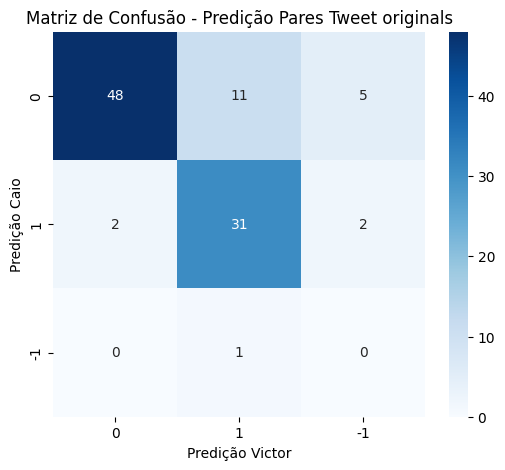

In [30]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_originals, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet originals")
plt.show()

In [31]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_originals)):
  print("Tweet 1: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_1"])
  print("Tweet 2: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_originals.loc[idx_diff_originals[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_originals.loc[idx_diff_originals[i], "Conflict"])])
  print()

Tweet 1:  #AbortoSim só pra subir a tag
Tweet 2:  O oportunismo da morte.  #AbortoNao
Classificação Caio:  Conflito
Classificação Victor:  Indeterminado

Tweet 1:  O Brasil vai ter que Ucranizar. #AbortoNAO #FiqueEmCasaMandetta #ChegouHoraDoChega  #BolsonaroEstavaCerto  #MonarquiaJa  #olavotemrazao
Tweet 2:  #AbortoSim #abortonao aproveitando que a discussão veio a tona, recomendo que assistam esse video do Canal do Slow:   E nessa casa nós somos #AbortoSIM
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Se um feto fosse um indivíduo dotado de direitos, incluindo o direito à vida, mulheres grávidas poderiam fazer seguro de vida ou até passar propriedades para eles. Teriam também desconto no imposto de renda por terem um dependente, já que fetos são “bebês”. #abortosim
Tweet 2:  STF aproveitando crise para legalizar aborto.  Não podemos permitir. #AbortoNao
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Em meio à pandemia e

In [32]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_replys = df_caio.drop('Conflict', axis = 1)
df_replys = df_replys.loc[:49,:]
df_replys['Conflict_Caio'] = df_caio['Conflict']
df_replys['Conflict_Victor'] = df_victor['Conflict']

In [33]:
df_replys

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0,0.0
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1,0.0,-1.0
6,É fácil defender o aborto sendo que você já na...,Há se as pessoas sobessem o mal que trszem par...,1,0.0,0.0
7,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Linda passagem da Bíblia. #AbortoNAO,1,0.0,0.0
8,Bolsominions estão revoltados pq STF pode perm...,É sobre as mulheres terem escolha. Se uma gest...,1,0.0,0.0
9,"O que a Bíblia fala sobre o aborto? ""Antes qu...",#AbortoNAO Minha nossa! Isso não!,1,-1.0,-1.0


In [34]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_quotes = df_caio_quotes.drop('Conflict',axis=1)
df_quotes = df_quotes.loc[:49,:]
df_quotes['Conflict_Caio'] = df_caio_quotes['Conflict']
df_quotes['Conflict_Victor'] = df_victor_quotes['Conflict']

In [35]:
df_quotes

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,STF quer aplicar a medida enquanto a gente não...,"Independente se você tem religião ou não, o tr...",2,0.0,0.0
1,"Eu peço a quem for a favor do aborto, para ref...",eu peço para que você faça mais por crianças j...,2,1.0,1.0
2,"Toffoli, um lacaio da OMS, pautou ADI do abort...",vc é um homem cis q se sua namorada engravidar...,2,1.0,1.0
3,"Médico pedófilo, Fábio Duarte, estava preso p/...",Difícil demais viver nesse País! A que ponto c...,2,0.0,0.0
4,#AbortoNao A hidroxicloroquina pode ter efeito...,Primeiramente #foradoria segundamente nao somo...,2,0.0,0.0
5,não acredito que ainda tenho que ficar lendo e...,O pior é ver mulheres defendendo esse tipo de ...,2,0.0,0.0
6,"Eu sou contra o aborto, o feto n tem nd a ver ...",quem aborta tem que morrer junto,2,0.0,0.0
7,"Bora subir, robozada? #AbortoNao","Difícil acreditar nesse corona virus, ele some...",2,0.0,0.0
8,Antes um feto abortado do que mais uma criança...,eu sigo as pessoas certas,2,0.0,0.0
9,Vamos começar a pressão ao STF já. #AbortoNAO,#AbortoNão Estão aproveitando a história do vi...,2,0.0,0.0


In [36]:
#Organizando classificações de conflitos em originals de Caio e Victor em um unico DF
df_originals = df_caio_originals.drop('Conflict',axis=1)
df_originals = df_originals.loc[:49,:]
df_originals['Conflict_Caio'] = df_caio_originals['Conflict']
df_originals['Conflict_Victor'] = df_victor_originals['Conflict']

In [37]:
df_originals

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0,0.0
5,Stf canalhas mil vezes #AbortoNao,#AbortoNAO Enquanto estamos em quarentena para...,0,0.0,0.0
6,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,1.0,-1.0
7,#AbortoNao E como sempre os abortistas não var...,quem quiser faz quem não quiser não faz simple...,0,1.0,1.0
8,"Vivemos em um Estado Laico, onde as decisões p...","STF pautou ABORTO para dia 24 , no auge da Pa...",0,1.0,1.0
9,sempre fui a favor da vida #AbortoNAO,#AbortoNunca Me poupe de homens ficarem dizend...,0,1.0,1.0


In [38]:
#concatenando os datasets parciais:
df_aborto_classificado = pd.concat([df_originals, df_replys, df_quotes], ignore_index=True, axis = 0)
df_aborto_classificado

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0,0.0
...,...,...,...,...,...
145,"entendi, então o bebe que pegue seu corpo e de...",Já terminou de tweetar # AbortoNao mulher bran...,2,1.0,1.0
146,Pq tem homem querendo opinar sobre aborto?,Sim mn #AbortoSim sem mais... Cada um com seu ...,2,0.0,0.0
147,LIBERA O CARAI DO ABORTO LOGO SEUS BANDO DE AR...,é por isso que eu amo essa mulher gente,2,0.0,0.0
148,Diga sim a vida #AbortoNAO,Show da vida!!,2,0.0,0.0


In [39]:
df_aborto_classificado.to_csv("aborto_classificado.csv", index=False, encoding="utf-8")
files.download("aborto_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [40]:
div_reply = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_quotes = df_caio_quotes.iloc[idx_diff_quotes].drop('Conflict', axis=1)
div_originals = df_caio_originals.iloc[idx_diff_originals].drop('Conflict', axis=1)

In [41]:
div_reply

,tweet_1,tweet_2,Class
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1
79,Vamos subir #AbortoNao . STF quer aprovar med...,ok mo calma aí #AbortoSim,1


In [42]:
div_originals

,tweet_1,tweet_2,Class
6,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0
15,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0
24,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0
27,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0
31,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0
32,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0
36,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0
45,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0
46,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0
52,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0


In [43]:
div_aborto = pd.concat([div_originals, div_reply, div_quotes], ignore_index=True, axis = 0)

In [44]:
div_aborto.shape

(31, 3)

In [45]:
div_aborto.to_csv("divergencias_aborto.csv", index=False, encoding="utf-8")
files.download("divergencias_aborto.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>